In [2]:
from pyau3d.utils import PltFileUtils, GrpFileUtils, UnkFileUtils
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation
import numpy as np
# imported experimental data
import pandas as pd

%matplotlib widget


In [3]:
# specify group for animation file
# group = 2 corresponds to cylinder wall - could double check in .an02 file
RE = 40
# cfd_dir = f"/home/ahf25/CFD_2d_cylinder_all/Steady/2d_cylinder_fine_Re{RE}"
cfd_dir = "/Users/User/Git/global_stability/2d_cylinder_inviscid_Re40"
plt_file = "cylinder.plt"
rst_file = "cylinder.rst"

# specify file paths
path2plt = cfd_dir  + "/" +  plt_file
path2rst = cfd_dir  + "/" +  rst_file


In [4]:
# Load necessary files
pltfile = PltFileUtils(path2plt)
rstfile = UnkFileUtils(path2rst, extend=False)

# Extract the side surface
side_coords, side_nodes, side_nodemap = pltfile.extract_surface(flag=3)

# note : flag = 3 is the flag on the out of plane surface, the xy plane
# flag = 4 is the bottom plane and flag = 3 is the top plane

# Compute flow primitives 
rstfile._primitive()

# Extract pressure values from the rst file, only at the side_nodes (top suface xy plane)
side_p = rstfile.p[side_nodes]

# Extract x-velocity values from the rst file, only at the side_nodes (top suface xy plane)
side_ux = rstfile.ux[side_nodes]

# Extract density values from the rst file, only at the side_nodes (top suface xy plane)
side_rho = rstfile.rho[side_nodes]


In [5]:
# use some utilities from GrpFileUtils
tmp_grp = GrpFileUtils('tmp', 0, 
                       read=False,
                       coord=side_coords, 
                       nodes=side_nodes)
tmp_grp.root_nodemap = side_nodemap 

In [6]:
# setting x and y bounds for the data
x_upper = 20
x_lower = -5
y_upper = 5
y_lower = -5

# Filter points based on x and y coordinate bounds 
node_filter = (side_coords[:, 0] > x_lower) & (side_coords[:, 0] < x_upper) & (side_coords[:, 1] > y_lower) & (side_coords[:, 1] < y_upper )
tmp_grp.node_filter = node_filter

# Extract triangle nodemap
tri_nodemap = tmp_grp.get_tri_nodemap() 

In [7]:
# saving the x and y coordinates to grp_x and grp_y

grp_x = tmp_grp.coords[:, 0]
grp_y = tmp_grp.coords[:, 1]
# Construct a matplotlib Triangulation (defines our mesh for plotting)
tri = Triangulation(grp_x, grp_y, triangles=tri_nodemap)

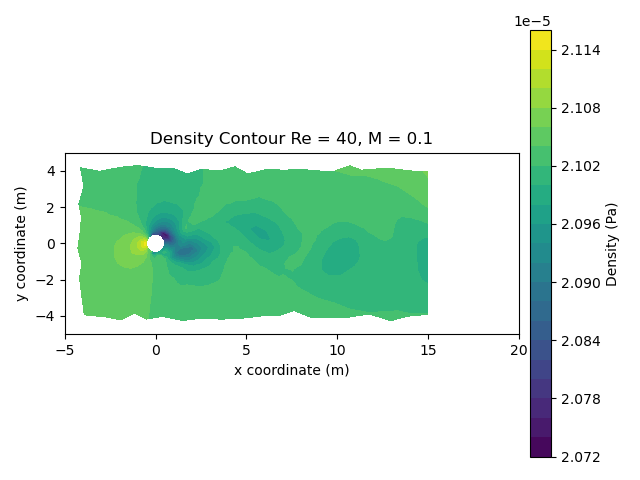

In [8]:
# density plot
fig, ax = plt.subplots()

# Note, we need to apply the node_filter to the pressure array 
# because it still contains values for every node on the casing
contour = ax.tricontourf(tri, side_rho[node_filter], levels=20)
fig.colorbar(contour, ax=ax, pad=0.02, label='Density (Pa)')
ax.set_title("Density Contour Re = 40, M = 0.1")
ax.set_xlabel("x coordinate (m)")
ax.set_ylabel("y coordinate (m)")
ax.set_aspect('equal', 'box') # forcing the scale of x and y axis to equal
ax.set_xlim(x_lower, x_upper)
ax.set_ylim(y_lower, y_upper)
plt.tight_layout()
plt.show()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


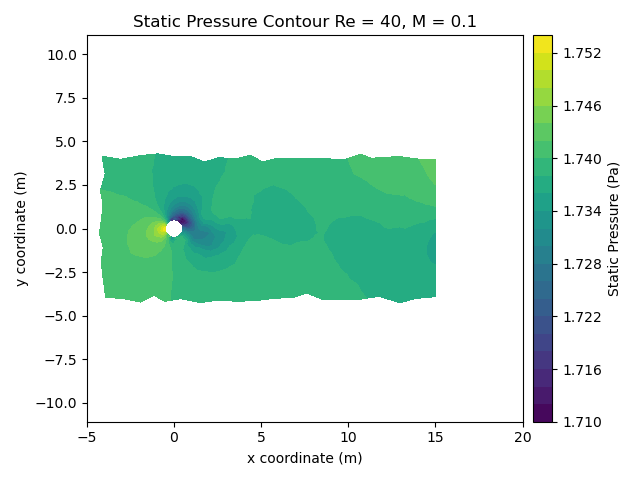

In [9]:

# plotting static pressure Pa
fig, ax = plt.subplots()

# Note, we need to apply the node_filter to the pressure array 
# because it still contains values for every node on the casing
contour = ax.tricontourf(tri, side_p[node_filter], levels=20)
fig.colorbar(contour, ax=ax, pad=0.02, label='Static Pressure (Pa)')
ax.set_title("Static Pressure Contour Re = 40, M = 0.1")
ax.set_xlabel("x coordinate (m)")
ax.set_ylabel("y coordinate (m)")
ax.axis('equal') # forcing the scale of x and y axis to equal
ax.set_xlim(x_lower, x_upper)
ax.set_ylim(y_lower, y_upper)
plt.tight_layout()
plt.show()


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


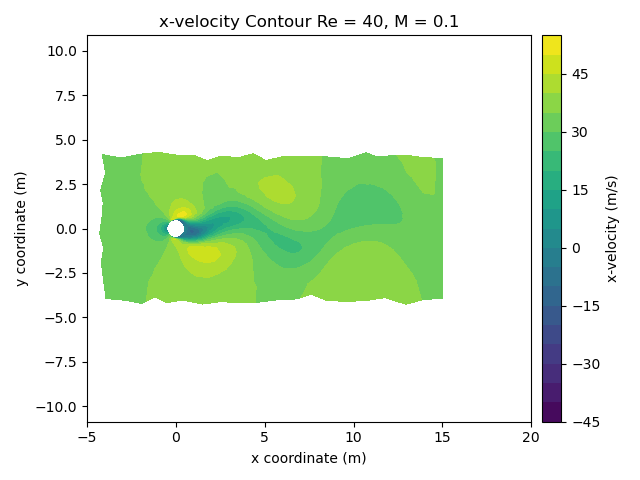

In [10]:
# plotting x-velocity
fig, ax = plt.subplots()

# Note, we need to apply the node_filter to the pressure array 
# because it still contains values for every node on the casing
contour = ax.tricontourf(tri, side_ux[node_filter], levels=20)
fig.colorbar(contour, ax=ax, pad=0.02, label='x-velocity (m/s)')
#ax.clabel(contour, inline=True, fontsize=8, fmt="%.2f", colors = "black")
ax.set_title("x-velocity Contour Re = 40, M = 0.1")
ax.set_xlabel("x coordinate (m)")
ax.set_ylabel("y coordinate (m)")
ax.axis('equal')
ax.set_xlim(x_lower, x_upper)
ax.set_ylim(y_lower, y_upper)
plt.tight_layout()
plt.show()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


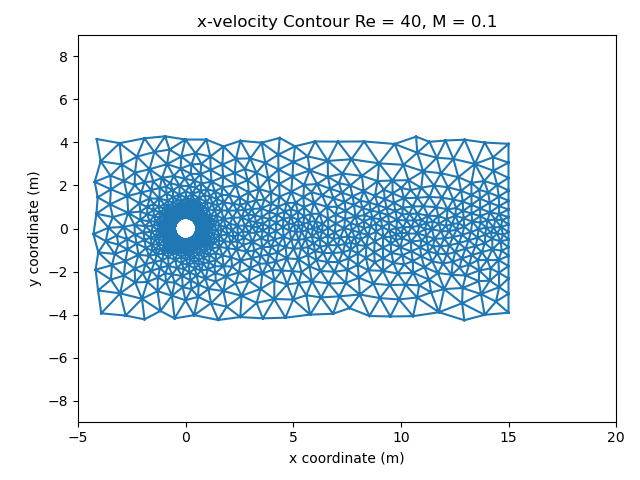

In [ ]:
# plot the mesh
fig, ax = plt.subplots()

contour = ax.triplot(tri)

#ax.clabel(contour, inline=True, fontsize=8, fmt="%.2f", colors = "black")
ax.set_title("x-velocity Contour Re = 40, M = 0.1")
ax.set_xlabel("x coordinate (m)")
ax.set_ylabel("y coordinate (m)")
ax.axis('equal')
ax.set_xlim(x_lower, x_upper)
ax.set_ylim(y_lower, y_upper)
plt.tight_layout()
plt.show()

# plot node number
# 5. Extract coordinates and overlay the node numbers
